In [1]:
# Recopilar resultados de todos los modelos (valores extraídos de los archivos metrics_*.jpg)
import pandas as pd

resultados_modelos = []

# 1. Regresión Logística
resultados_modelos.append({
    'Modelo': 'Regresión Logística',
    'Acc Train': 0.7071,
    'Acc Test': 0.6322,
    'Acc CV': 0.6238,
    'Precision': 0.63,
    'Recall': 0.63,
    'F1-Score': 0.63
})

# 2. SVM RBF
resultados_modelos.append({
    'Modelo': 'SVM RBF',
    'Acc Train': 1.0000,
    'Acc Test': 0.7117,
    'Acc CV': 0.6814,
    'Precision': 0.80,
    'Recall': 0.71,
    'F1-Score': 0.69
})

# 3. K-Nearest Neighbors
resultados_modelos.append({
    'Modelo': 'K-Nearest Neighbors',
    'Acc Train': 0.8189,
    'Acc Test': 0.6597,
    'Acc CV': 0.6188,
    'Precision': 0.76,
    'Recall': 0.66,
    'F1-Score': 0.65
})

# 4. Naive Bayes
resultados_modelos.append({
    'Modelo': 'Naive Bayes',
    'Acc Train': 0.6589,
    'Acc Test': 0.5565,
    'Acc CV': 0.5211,
    'Precision': 0.76,
    'Recall': 0.66,
    'F1-Score': 0.65
})

# 5. Decision Tree
resultados_modelos.append({
    'Modelo': 'Decision Tree',
    'Acc Train': 0.9547,
    'Acc Test': 0.7522,
    'Acc CV': 0.7351,
    'Precision': 0.75,
    'Recall': 0.75,
    'F1-Score': 0.75
})

# 6. Random Forest
resultados_modelos.append({
    'Modelo': 'Random Forest',
    'Acc Train': 0.9979,
    'Acc Test': 0.5667,
    'Acc CV': 0.5083,
    'Precision': 0.60,
    'Recall': 0.57,
    'F1-Score': 0.54
})

# 7. Perceptron
resultados_modelos.append({
    'Modelo': 'Perceptron',
    'Acc Train': 0.7125,
    'Acc Test': 0.4250,
    'Acc CV': 0.4437,
    'Precision': 0.34,
    'Recall': 0.42,
    'F1-Score': 0.36
})

# 8. MLP
resultados_modelos.append({
    'Modelo': 'MLP',
    'Acc Train': 1.0000,
    'Acc Test': 0.5833,
    'Acc CV': 0.5271,
    'Precision': 0.58,
    'Recall': 0.58,
    'F1-Score': 0.58
})

# 9. Gradient Boost
resultados_modelos.append({
    'Modelo': 'Gradient Boost',
    'Acc Train': 1.0000,
    'Acc Test': 0.5083,
    'Acc CV': 0.4875,
    'Precision': 0.57,
    'Recall': 0.51,
    'F1-Score': 0.51
})

# 10. Stacking Classifier
resultados_modelos.append({
    'Modelo': 'Stacking Classifier',
    'Acc Train': 0.8354,
    'Acc Test': 0.4250,
    'Acc CV': 0.4000,
    'Precision': 0.63,
    'Recall': 0.42,
    'F1-Score': 0.42
})

# Crear DataFrame
df_resultados = pd.DataFrame(resultados_modelos)

# Calcular diferencia Train-Test (overfitting)
df_resultados['Diff Train-Test'] = df_resultados['Acc Train'] - df_resultados['Acc Test']

# Ordenar por Accuracy Test (descendente)
df_resultados = df_resultados.sort_values('Acc Test', ascending=False).reset_index(drop=True)

# Mostrar tabla
print("\n" + "="*100)
print("COMPARACIÓN FINAL DE MODELOS")
print("="*100)
print(df_resultados.to_string(index=False))
print("="*100)

# Análisis rápido
print(f"\n📊 RESUMEN:")
print(f"  Mejor Accuracy Test: {df_resultados.iloc[0]['Modelo']} ({df_resultados.iloc[0]['Acc Test']:.4f})")
print(f"  Mejor F1-Score: {df_resultados.loc[df_resultados['F1-Score'].idxmax(), 'Modelo']} ({df_resultados['F1-Score'].max():.4f})")
print(f"  Menor Overfitting: {df_resultados.loc[df_resultados['Diff Train-Test'].idxmin(), 'Modelo']} ({df_resultados['Diff Train-Test'].min():.4f})")
print(f"  Mayor Overfitting: {df_resultados.loc[df_resultados['Diff Train-Test'].idxmax(), 'Modelo']} ({df_resultados['Diff Train-Test'].max():.4f})")



COMPARACIÓN FINAL DE MODELOS
             Modelo  Acc Train  Acc Test  Acc CV  Precision  Recall  F1-Score  Diff Train-Test
      Decision Tree     0.9547    0.7522  0.7351       0.75    0.75      0.75           0.2025
            SVM RBF     1.0000    0.7117  0.6814       0.80    0.71      0.69           0.2883
K-Nearest Neighbors     0.8189    0.6597  0.6188       0.76    0.66      0.65           0.1592
Regresión Logística     0.7071    0.6322  0.6238       0.63    0.63      0.63           0.0749
                MLP     1.0000    0.5833  0.5271       0.58    0.58      0.58           0.4167
      Random Forest     0.9979    0.5667  0.5083       0.60    0.57      0.54           0.4312
        Naive Bayes     0.6589    0.5565  0.5211       0.76    0.66      0.65           0.1024
     Gradient Boost     1.0000    0.5083  0.4875       0.57    0.51      0.51           0.4917
         Perceptron     0.7125    0.4250  0.4437       0.34    0.42      0.36           0.2875
Stacking Classifier 

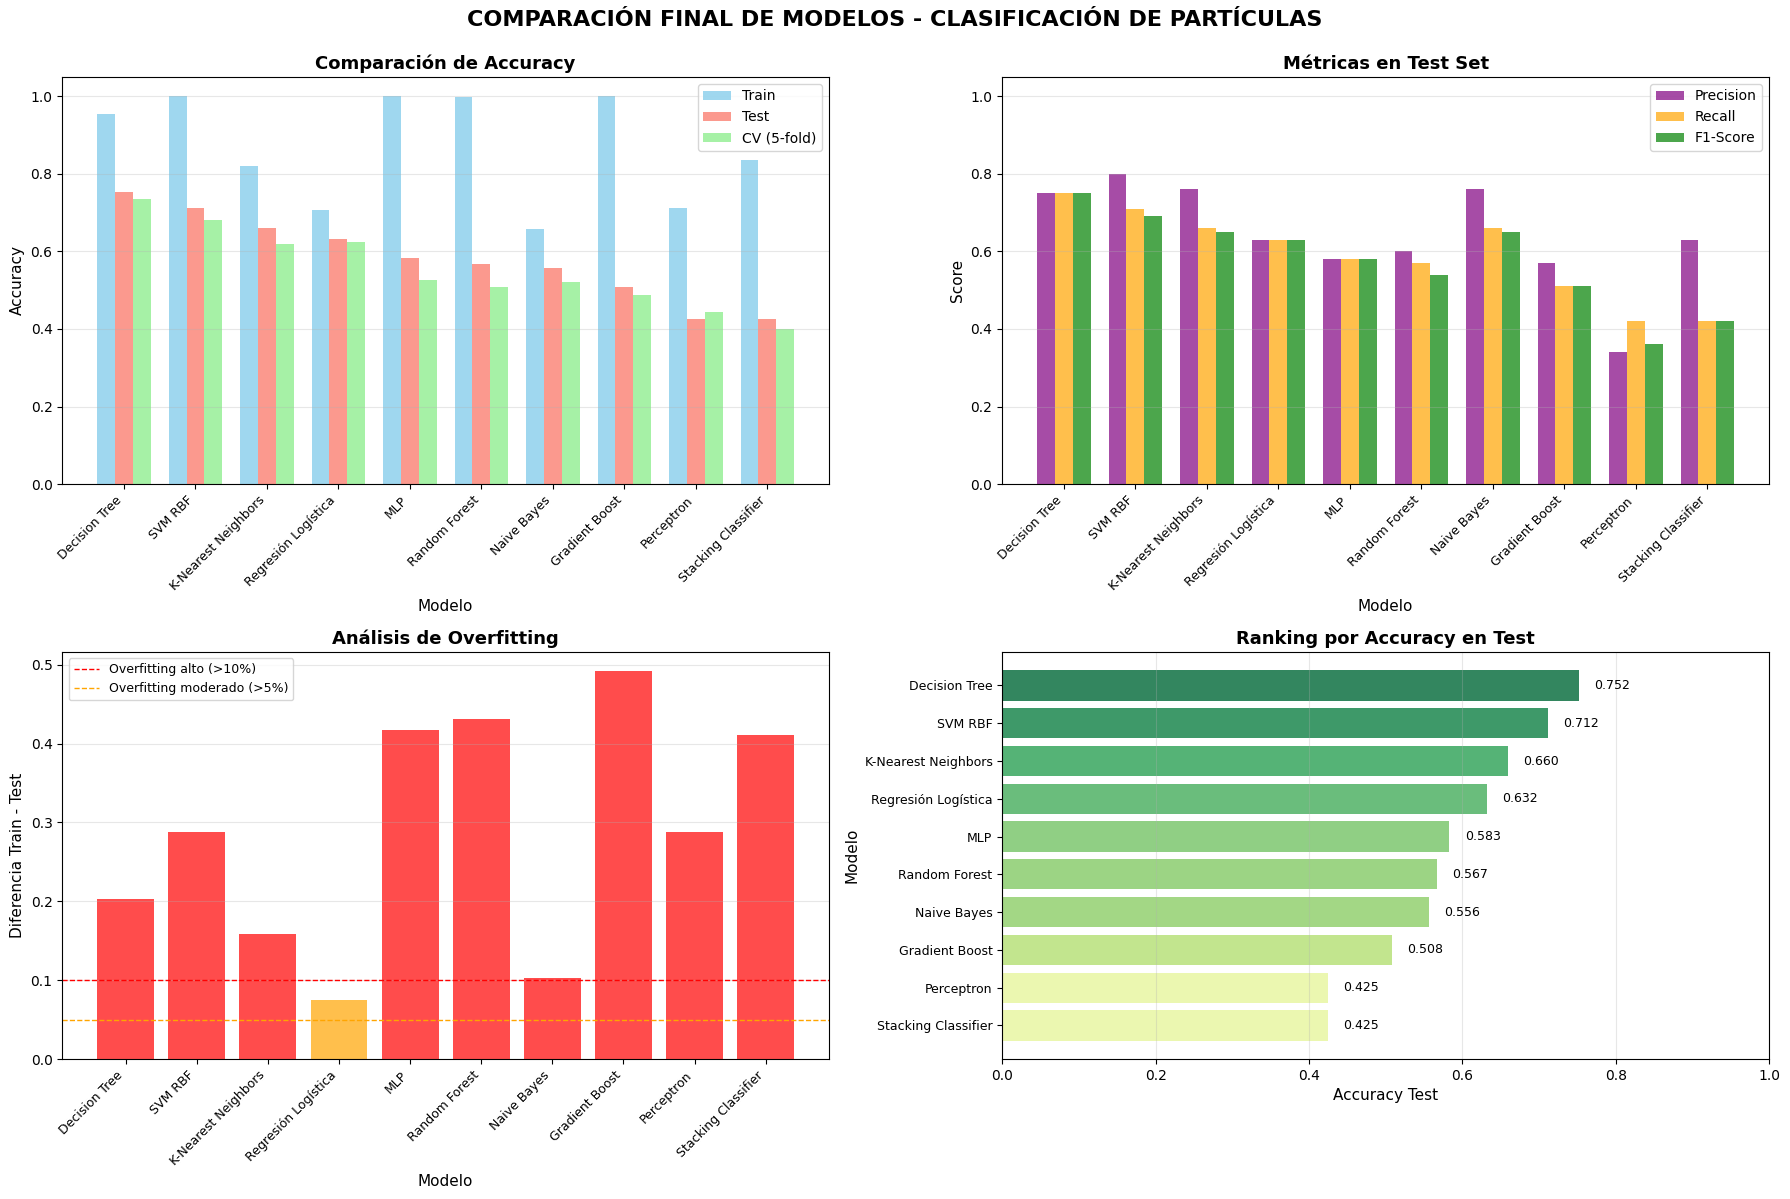


 Interpretación:
  - Verde: Buen rendimiento / Bajo overfitting
  - Naranja: Rendimiento moderado / Overfitting moderado
  - Rojo: Bajo rendimiento / Alto overfitting


In [2]:
# Gráfico comparativo de métricas
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Subplot 1: Accuracy (Train, Test, CV)
ax1 = axes[0, 0]
x_pos = np.arange(len(df_resultados))
width = 0.25

ax1.bar(x_pos - width, df_resultados['Acc Train'], width, label='Train', color='skyblue', alpha=0.8)
ax1.bar(x_pos, df_resultados['Acc Test'], width, label='Test', color='salmon', alpha=0.8)
ax1.bar(x_pos + width, df_resultados['Acc CV'], width, label='CV (5-fold)', color='lightgreen', alpha=0.8)

ax1.set_xlabel('Modelo', fontsize=11)
ax1.set_ylabel('Accuracy', fontsize=11)
ax1.set_title('Comparación de Accuracy', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right', fontsize=9)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.05])

# Subplot 2: Métricas Test (Precision, Recall, F1-Score)
ax2 = axes[0, 1]
width2 = 0.25

ax2.bar(x_pos - width2, df_resultados['Precision'], width2, label='Precision', color='purple', alpha=0.7)
ax2.bar(x_pos, df_resultados['Recall'], width2, label='Recall', color='orange', alpha=0.7)
ax2.bar(x_pos + width2, df_resultados['F1-Score'], width2, label='F1-Score', color='green', alpha=0.7)

ax2.set_xlabel('Modelo', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Métricas en Test Set', fontsize=13, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right', fontsize=9)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, 1.05])

# Subplot 3: Overfitting (Diferencia Train-Test)
ax3 = axes[1, 0]
colors = ['red' if x > 0.1 else 'orange' if x > 0.05 else 'green' for x in df_resultados['Diff Train-Test']]
ax3.bar(x_pos, df_resultados['Diff Train-Test'], color=colors, alpha=0.7)
ax3.axhline(y=0.1, color='red', linestyle='--', linewidth=1, label='Overfitting alto (>10%)')
ax3.axhline(y=0.05, color='orange', linestyle='--', linewidth=1, label='Overfitting moderado (>5%)')

ax3.set_xlabel('Modelo', fontsize=11)
ax3.set_ylabel('Diferencia Train - Test', fontsize=11)
ax3.set_title('Análisis de Overfitting', fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(df_resultados['Modelo'], rotation=45, ha='right', fontsize=9)
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# Subplot 4: Ranking por Accuracy Test
ax4 = axes[1, 1]
df_sorted = df_resultados.sort_values('Acc Test', ascending=True)
colors_rank = plt.cm.RdYlGn(df_sorted['Acc Test'] / df_sorted['Acc Test'].max())

y_pos = np.arange(len(df_sorted))
ax4.barh(y_pos, df_sorted['Acc Test'], color=colors_rank, alpha=0.8)

ax4.set_xlabel('Accuracy Test', fontsize=11)
ax4.set_ylabel('Modelo', fontsize=11)
ax4.set_title('Ranking por Accuracy en Test', fontsize=13, fontweight='bold')
ax4.set_yticks(y_pos)
ax4.set_yticklabels(df_sorted['Modelo'], fontsize=9)
ax4.grid(axis='x', alpha=0.3)
ax4.set_xlim([0, 1.0])

# Añadir valores en las barras
for i, v in enumerate(df_sorted['Acc Test']):
    ax4.text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('COMPARACIÓN FINAL DE MODELOS - CLASIFICACIÓN DE PARTÍCULAS', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n Interpretación:")
print("  - Verde: Buen rendimiento / Bajo overfitting")
print("  - Naranja: Rendimiento moderado / Overfitting moderado")
print("  - Rojo: Bajo rendimiento / Alto overfitting")
